# ✈️ Flight Delay Prediction — Modeling
### Data Bootcamp Final Project

**Dataset:** 2015 Flight Delays and Cancellations (Kaggle / USDOT)  
**Notebook scope:** Feature engineering, model training, evaluation, and results  
**Models:** Logistic Regression, K-Nearest Neighbors, Decision Tree, Naive Bayes, Random Forest

---

> **Prerequisites:** Run the EDA notebook first to load `flights`, `airlines`, `airports` DataFrames,  
> and produce the cleaned `df` used here.

---

## 📋 Table of Contents
1. [Re-run Setup (imports + data load)](#setup)
2. [Feature Engineering](#features)
3. [Modeling](#modeling)
4. [Results & Interpretation](#results)
5. [Conclusion & Next Steps](#conclusion)


## 1. Re-run Setup <a id='setup'></a>
Re-run imports, data loading, and preprocessing to make this notebook self-contained.


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Make sure flights.csv, airlines.csv, airports.csv are in the same folder as this notebook
flights  = pd.read_csv('../data/flights.csv',  low_memory=False)
airlines = pd.read_csv('../data/airlines.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights shape:  {flights.shape}')
print(f'airlines shape: {airlines.shape}')
print(f'airports shape: {airports.shape}')

flights shape:  (5819079, 31)
airlines shape: (14, 2)
airports shape: (322, 7)


In [3]:
flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [5]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


---
## 3. Data Preprocessing <a id='preprocessing'></a>

Key steps:
1. **Create binary target FIRST** — derive `DELAYED` from `ARRIVAL_DELAY` before dropping any columns
2. **Drop data-leakage columns** — remove anything only known after the flight lands
3. **Handle missing values** — rows with missing target or key features are dropped
4. **Sample** — use 200k rows for manageable runtime

In [6]:
# ── 3.1 Create binary target BEFORE dropping ARRIVAL_DELAY ───────────────────
# FAA standard: a flight is 'delayed' if it arrives more than 15 minutes late
# CANCELLED flights have NaN in ARRIVAL_DELAY — we exclude them
flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype('Int64')  # Int64 handles NaN

print('Class distribution (full dataset):')
print(flights['DELAYED'].value_counts(dropna=True, normalize=True).round(3))

Class distribution (full dataset):
DELAYED
0    0.824
1    0.176
Name: proportion, dtype: Float64


In [7]:
# ── 3.2 Drop post-flight leakage columns ─────────────────────────────────────
# These columns are only known AFTER the flight — using them would be cheating!
drop_cols = [
    'YEAR',                   # constant (all 2015), no predictive value
    'FLIGHT_NUMBER',          # flight ID, not a meaningful feature
    'TAIL_NUMBER',            # plane ID, too many unique values
    'DEPARTURE_TIME',         # actual departure — not known pre-flight
    'DEPARTURE_DELAY',        # measured at departure gate — slight leakage
    'TAXI_OUT',               # post-departure
    'WHEELS_OFF',             # post-departure
    'ELAPSED_TIME',           # post-flight
    'AIR_TIME',               # post-flight
    'WHEELS_ON',              # post-flight
    'TAXI_IN',                # post-flight
    'SCHEDULED_ARRIVAL',      # derivable from SCHEDULED_DEPARTURE + SCHEDULED_TIME
    'ARRIVAL_TIME',           # post-flight
    'ARRIVAL_DELAY',          # this IS our target — already used above
    'DIVERTED',               # post-flight outcome
    'CANCELLED',              # post-flight outcome
    'CANCELLATION_REASON',    # post-flight outcome
    'AIR_SYSTEM_DELAY',       # post-flight breakdown
    'SECURITY_DELAY',         # post-flight breakdown
    'AIRLINE_DELAY',          # post-flight breakdown
    'LATE_AIRCRAFT_DELAY',    # post-flight breakdown
    'WEATHER_DELAY',          # post-flight breakdown
]

# Only drop columns that actually exist (safe against version differences)
drop_cols = [c for c in drop_cols if c in flights.columns]
df = flights.drop(columns=drop_cols).copy()

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'DELAYED']


In [8]:
# ── 3.3 Handle missing values ─────────────────────────────────────────────────
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Drop rows where target is missing (cancelled flights have no ARRIVAL_DELAY)
df = df.dropna(subset=['DELAYED'])
# Drop rows missing key pre-flight features
df = df.dropna(subset=['SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
                        'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])
df = df.reset_index(drop=True)
print(f'\nRows after dropping NA: {len(df):,}')

Missing values per column:
SCHEDULED_TIME    6
dtype: int64

Rows after dropping NA: 5,819,073


In [9]:
# ── 3.4 Derive HOUR feature from SCHEDULED_DEPARTURE ─────────────────────────
# SCHEDULED_DEPARTURE is stored as HHMM integer e.g. 1530 = 15:30
df['HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

print('HOUR sample values:', df['HOUR'].unique()[:10])

HOUR sample values: [0 1 2 3 4 5 6 7 8 9]


In [10]:
# ── 3.5 Sample for manageable runtime (~200k rows) ────────────────────────────
df = df.sample(n=min(200_000, len(df)), random_state=SEED).reset_index(drop=True)
# Convert DELAYED back to plain int after sampling
df['DELAYED'] = df['DELAYED'].astype(int)
print(f'Working dataset size: {len(df):,}')
print(f'Delay rate: {df["DELAYED"].mean():.1%}')

Working dataset size: 200,000
Delay rate: 17.6%


---
## 5. Feature Engineering <a id='features'></a>

We select features that are known **before** the flight departs:
- **Categorical:** `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT` → One-Hot Encoded
- **Numeric:** `MONTH`, `DAY`, `DAY_OF_WEEK`, `HOUR`, `SCHEDULED_TIME`, `DISTANCE` → StandardScaled

To reduce the dimensionality of airport one-hot encoding, we group the bottom airports into an `OTHER` category.

In [28]:
# ── 5.1 Reduce airport cardinality ───────────────────────────────────────────
# Keep only the top 30 most frequent airports; rest become 'OTHER'
top_origins = df['ORIGIN_AIRPORT'].value_counts().head(30).index
top_dests   = df['DESTINATION_AIRPORT'].value_counts().head(30).index

df['ORIGIN_AIRPORT']      = df['ORIGIN_AIRPORT'].where(df['ORIGIN_AIRPORT'].isin(top_origins), other='OTHER')
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].where(df['DESTINATION_AIRPORT'].isin(top_dests), other='OTHER')

print('Unique origin airports after grouping:     ', df['ORIGIN_AIRPORT'].nunique())
print('Unique destination airports after grouping:', df['DESTINATION_AIRPORT'].nunique())

Unique origin airports after grouping:      31
Unique destination airports after grouping: 31


In [29]:
# ── 5.2 Define feature sets and build model dataframe ────────────────────────
cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
num_features = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'HOUR', 'SCHEDULED_TIME', 'DISTANCE']
all_features = cat_features + num_features

df_model = df[all_features + ['DELAYED']].dropna()
print(f'Model dataset shape: {df_model.shape}')
print(f'Features: {all_features}')

Model dataset shape: (200000, 10)
Features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'HOUR', 'SCHEDULED_TIME', 'DISTANCE']


In [30]:
# ── 5.3 Train / Test Split (stratified to preserve class ratio) ───────────────
X = df_model[all_features]
y = df_model['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train delay rate: {y_train.mean():.1%}  |  Test delay rate: {y_test.mean():.1%}')

Train size: 160,000  |  Test size: 40,000
Train delay rate: 17.6%  |  Test delay rate: 17.6%


In [31]:
# ── 5.4 Preprocessor — same pattern as class ──────────────────────────────────
preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
    remainder=StandardScaler()
)
print('Preprocessor built ✓')

Preprocessor built ✓


---
## 6. Modeling <a id='modeling'></a>

We train three models in increasing complexity, each wrapped in a `Pipeline`:
1. **Logistic Regression** — interpretable linear baseline
2. **K-Nearest Neighbors (k=5)** — non-parametric, similarity-based
3. **Random Forest** — ensemble of decision trees, captures non-linearity

### ⚠️ Handling Class Imbalance
Our dataset is imbalanced: **82.4% On Time vs 17.6% Delayed**. Without correction, a model trivially achieves 82.4% accuracy by always predicting 'On Time' — making it completely useless for catching real delays (Recall ≈ 0).

**Solution: `class_weight='balanced'`** instructs the model to penalize mistakes on the minority class (Delayed) proportionally more, forcing it to actually learn delay patterns. KNN does not support `class_weight`, so we downsample the training set to a 50/50 balance for that model.

In [32]:
# ── 6.1 Build Pipelines (with class_weight='balanced') ───────────────────────
lgr_pipe = Pipeline([
    ('transform', preprocessor),
    ('model', LogisticRegression(max_iter=500, random_state=SEED,
                                  class_weight='balanced'))   # fix imbalance
])

# KNN doesn't support class_weight — downsample training set to 50/50 instead
delayed_train   = X_train[y_train == 1]
on_time_train   = X_train[y_train == 0].sample(n=len(delayed_train), random_state=SEED)
X_train_knn     = pd.concat([delayed_train, on_time_train])
y_train_knn     = pd.concat([y_train[y_train == 1],
                              y_train[y_train == 0].loc[on_time_train.index]])

knn_pipe = Pipeline([
    ('transform', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

rf_pipe = Pipeline([
    ('transform', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=10,
                                      random_state=SEED, n_jobs=-1,
                                      class_weight='balanced'))  # fix imbalance
])

dt_pipe = Pipeline([
    ('transform', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=SEED,
                                      class_weight='balanced'))
])

nb_pipe = Pipeline([
    ('transform', preprocessor),
    ('model', GaussianNB())
    # GaussianNB 不支持 class_weight，但对不平衡数据本身有一定鲁棒性
])

print('All pipelines created ✓')
print(f'KNN balanced training set: {len(X_train_knn):,} rows ({y_train_knn.mean():.0%} delayed)')

All pipelines created ✓
KNN balanced training set: 56,278 rows (50% delayed)


In [33]:
# ── 6.2 Train ─────────────────────────────────────────────────────────────────
print('Training Logistic Regression...', end=' ')
lgr_pipe.fit(X_train, y_train)
print('done ✓')

print('Training KNN (on balanced subset)...', end=' ')
knn_pipe.fit(X_train_knn, y_train_knn)
print('done ✓')

print('Training Random Forest...', end=' ')
rf_pipe.fit(X_train, y_train)
print('done ✓')

print('Training Decision Tree...', end=' ')
dt_pipe.fit(X_train, y_train)
print('done ✓')

print('Training Naive Bayes...', end=' ')
nb_pipe.fit(X_train, y_train)
print('done ✓')

Training Logistic Regression... done ✓
Training KNN (on balanced subset)... done ✓
Training Random Forest... done ✓
Training Decision Tree... done ✓
Training Naive Bayes... done ✓


In [34]:
# ── 6.3 Generate predictions ──────────────────────────────────────────────────
lgr_preds = lgr_pipe.predict(X_test)
knn_preds = knn_pipe.predict(X_test)
rf_preds  = rf_pipe.predict(X_test)

lgr_proba = lgr_pipe.predict_proba(X_test)[:, 1]
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]
rf_proba  = rf_pipe.predict_proba(X_test)[:, 1]

dt_preds = dt_pipe.predict(X_test)
nb_preds = nb_pipe.predict(X_test)

dt_proba = dt_pipe.predict_proba(X_test)[:, 1]
nb_proba = nb_pipe.predict_proba(X_test)[:, 1]

print('Predictions generated ✓')

Predictions generated ✓


Best max_depth: {'model__max_depth': 1}
Best CV Recall: 0.7137
Test Recall:    0.7082
Test ROC-AUC:   0.5761


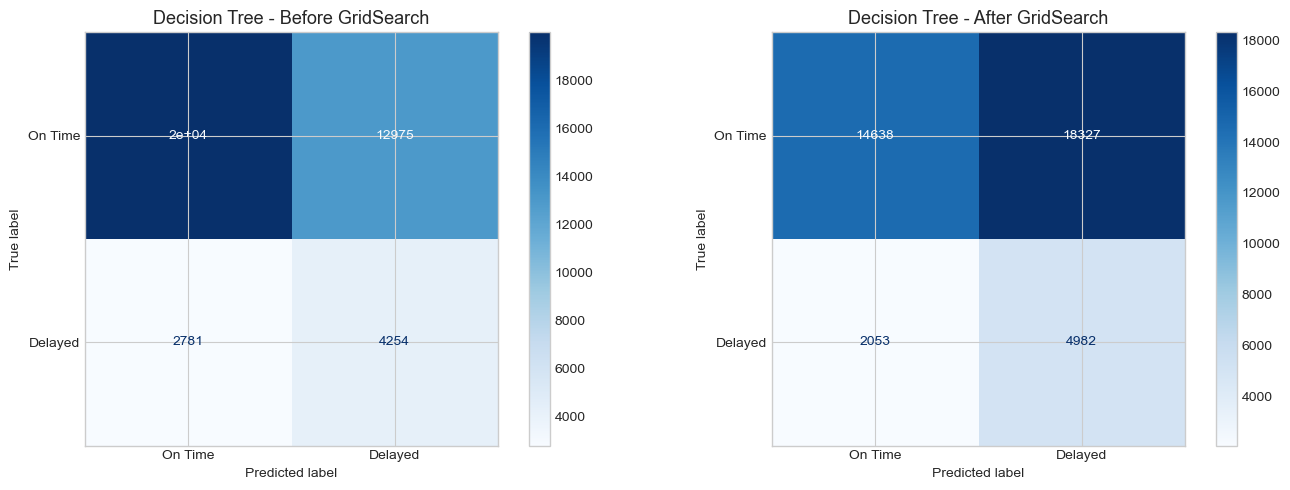

In [ ]:
# ── Modeling Extension 1: GridSearchCV on Decision Tree ───────────────────────
from sklearn.model_selection import GridSearchCV


params_dt = {'model__max_depth': np.arange(1, 21, 2)}

grid_dt = GridSearchCV(
    dt_pipe,        
    params_dt,
    cv=5,
    scoring='recall', 
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Best max_depth:", grid_dt.best_params_)
print("Best CV Recall:", round(grid_dt.best_score_, 4))
print("Test Recall:   ", round(recall_score(y_test, grid_dt.predict(X_test)), 4))
print("Test ROC-AUC:  ", round(roc_auc_score(y_test, 
      grid_dt.predict_proba(X_test)[:,1]), 4))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(
    dt_pipe, X_test, y_test, ax=axes[0],
    display_labels=['On Time', 'Delayed'], cmap='Blues'
)
axes[0].set_title('Decision Tree - Before GridSearch', fontsize=13)

ConfusionMatrixDisplay.from_estimator(
    grid_dt, X_test, y_test, ax=axes[1],
    display_labels=['On Time', 'Delayed'], cmap='Blues'
)
axes[1].set_title('Decision Tree - After GridSearch', fontsize=13)
plt.tight_layout()
plt.show()

Logistic Regression      : Max profit = $318,330 at 53.3%
KNN                      : Max profit = $1,191,100 at 59.9%
Decision Tree            : Max profit = $418,390 at 47.0%
Decision Tree (tuned)    : Max profit = $267,100 at 58.6%
Random Forest            : Max profit = $413,620 at 49.9%


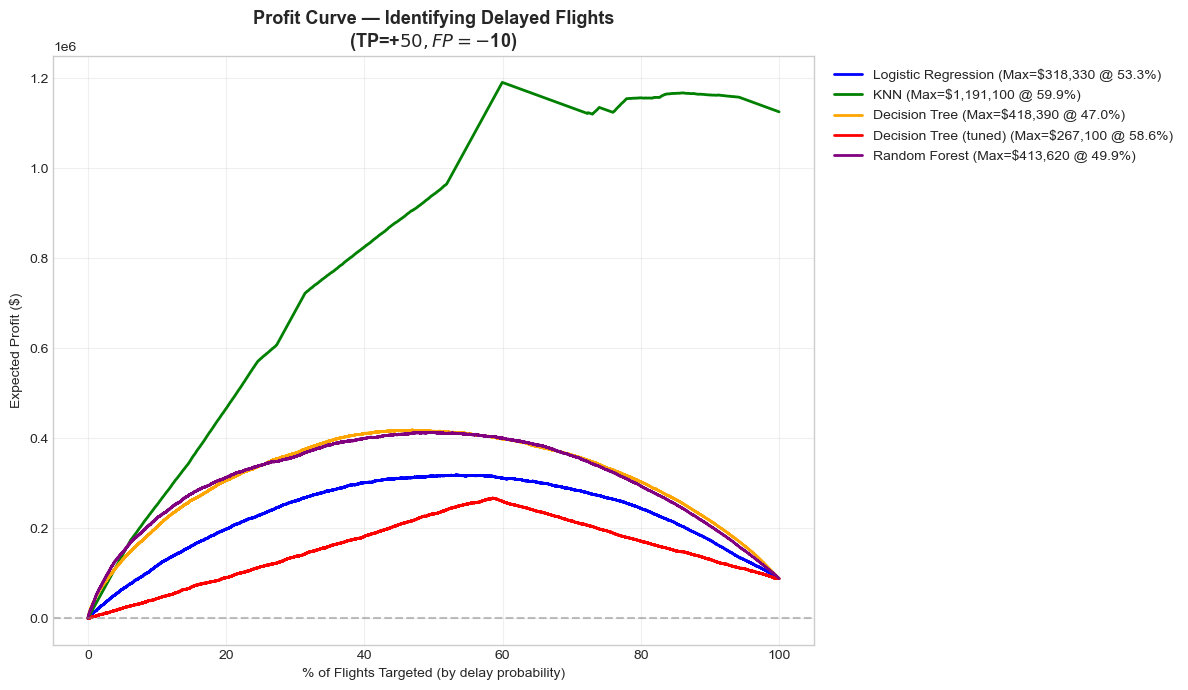

In [ ]:
# ── Modeling Extension 2: Profit Curve ────────────────────────────────────────
# Cost matrix:
# TP (correctly identify delayed flight): +$50
# FP (wrongly flag on-time flight):       -$10

def plot_profit_curve(model, X, y, tp_value=50, fp_cost=-10, label='', color='blue'):
    y_proba = model.predict_proba(X)[:, 1]
    sorted_idx = np.argsort(y_proba)[::-1]
    y_sorted = np.array(y)[sorted_idx]

    profits, percentages = [], []
    for i in range(1, len(y_sorted) + 1):
        tp = np.sum(y_sorted[:i] == 1)
        fp = i - tp
        profits.append(tp * tp_value + fp * fp_cost)
        percentages.append(i / len(y_sorted) * 100)

    max_profit = max(profits)
    max_pct = percentages[profits.index(max_profit)]

    plt.plot(percentages, profits,
             label=f'{label} (Max=${max_profit:,} @ {max_pct:.1f}%)',
             color=color, linewidth=2)
    return max_profit, max_pct

plt.figure(figsize=(12, 7))


models_info = [
    (lgr_pipe, X_train,     y_train,     'Logistic Regression',    'blue'),
    (knn_pipe, X_train_knn, y_train_knn, 'KNN',                    'green'),
    (dt_pipe,  X_train,     y_train,     'Decision Tree',          'orange'),
    (grid_dt,  X_train,     y_train,     'Decision Tree (tuned)',   'red'),
    (rf_pipe,  X_train,     y_train,     'Random Forest',          'purple'),
]

for model, X, y, name, color in models_info:
    try:
        max_p, max_pct = plot_profit_curve(
            model, X, y, label=name, color=color
        )
        print(f"{name:25s}: Max profit = ${max_p:,} at {max_pct:.1f}%")
    except Exception as e:
        print(f"{name}: skipped ({e})")

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('% of Flights Targeted (by delay probability)')
plt.ylabel('Expected Profit ($)')
plt.title('Profit Curve — Identifying Delayed Flights\n(TP=+$50, FP=-$10)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Added Part

EXTENDED ANALYSIS: Multi-Class Delay Prediction

Multi-class label distribution:
DELAY_CLASS
On Time        161787
Short Delay     20133
Long Delay      15041
Cancelled        3039
Name: count, dtype: int64



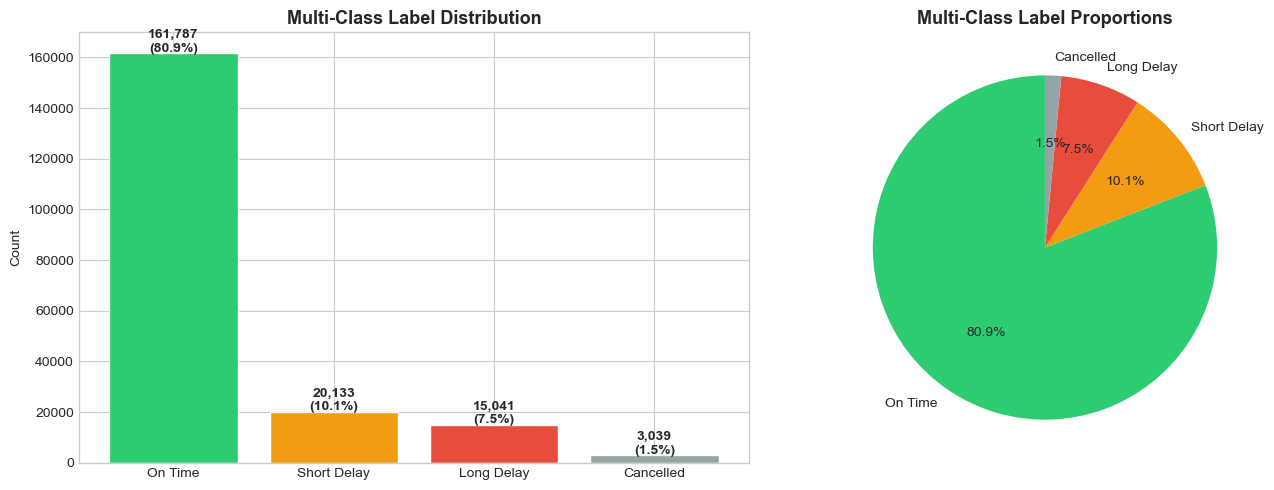

In [ ]:
# ── Modeling Extension 3: Multi-Class Delay Prediction ────────────────────────


print("=" * 60)
print("EXTENDED ANALYSIS: Multi-Class Delay Prediction")
print("=" * 60)

# Step 1: 
flights_mc = flights.copy()
flights_mc['ARRIVAL_DELAY'] = flights_mc['ARRIVAL_DELAY'].fillna(0)

def create_delay_class(row):
    if row['CANCELLED'] == 1:
        return 'Cancelled'
    elif row['ARRIVAL_DELAY'] <= 15:
        return 'On Time'
    elif row['ARRIVAL_DELAY'] <= 45:
        return 'Short Delay'
    else:
        return 'Long Delay'

flights_mc['DELAY_CLASS'] = flights_mc.apply(create_delay_class, axis=1)

# Step 2: 
sample_mc = flights_mc.dropna(subset=[
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME', 'DISTANCE'
]).sample(n=200000, random_state=42).copy()


sample_mc['HOUR'] = sample_mc['SCHEDULED_DEPARTURE'] // 100

print("\nMulti-class label distribution:")
print(sample_mc['DELAY_CLASS'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = sample_mc['DELAY_CLASS'].value_counts()
cat_order = ['On Time', 'Short Delay', 'Long Delay', 'Cancelled']
counts = counts.reindex(cat_order)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
for i, (cat, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 500, f'{cnt:,}\n({cnt/len(sample_mc)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Multi-Class Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Multi-Class Label Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Step 3:
top_origins = (sample_mc['ORIGIN_AIRPORT']
               .value_counts().head(30).index.tolist())
top_dests   = (sample_mc['DESTINATION_AIRPORT']
               .value_counts().head(30).index.tolist())

sample_mc['ORIGIN_AIRPORT'] = sample_mc['ORIGIN_AIRPORT'].apply(
    lambda x: x if x in top_origins else 'OTHER'
)
sample_mc['DESTINATION_AIRPORT'] = sample_mc['DESTINATION_AIRPORT'].apply(
    lambda x: x if x in top_dests else 'OTHER'
)

# Step 4: 
cat_features_mc = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
num_features_mc = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'HOUR',
                   'SCHEDULED_TIME', 'DISTANCE']

X_mc = sample_mc[cat_features_mc + num_features_mc]
y_mc = sample_mc['DELAY_CLASS']

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42
)

print(f"Train size: {X_train_mc.shape}")
print(f"Test size:  {X_test_mc.shape}")
print(f"\nClass distribution in train:")
print(y_train_mc.value_counts())

Train size: (160000, 9)
Test size:  (40000, 9)

Class distribution in train:
DELAY_CLASS
On Time        129427
Short Delay     16172
Long Delay      11935
Cancelled        2466
Name: count, dtype: int64


In [ ]:
# Step 5: 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

ohe_mc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ct_mc = make_column_transformer(
    (ohe_mc, cat_features_mc),
    remainder=StandardScaler()
)

# Logistic Regression
lr_mc = Pipeline([
    ('transform', ct_mc),
    ('model', LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced'  
    ))
])

# Decision Tree
dt_mc = Pipeline([
    ('transform', ct_mc),
    ('model', DecisionTreeClassifier(
        max_depth=10, random_state=42,
        class_weight='balanced'
    ))
])

# Random Forest
rf_mc = Pipeline([
    ('transform', ct_mc),
    ('model', RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight='balanced', n_jobs=-1
    ))
])

# Step 6: 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

mc_models = [
    (lr_mc,  'Logistic Regression'),
    (dt_mc,  'Decision Tree'),
    (rf_mc,  'Random Forest'),
]

mc_results = []
for pipe, name in mc_models:
    pipe.fit(X_train_mc, y_train_mc)
    train_acc = pipe.score(X_train_mc, y_train_mc)
    test_acc  = pipe.score(X_test_mc,  y_test_mc)
    mc_results.append({
        'Model': name,
        'Train Acc': round(train_acc, 4),
        'Test Acc':  round(test_acc,  4)
    })
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    print(classification_report(y_test_mc, pipe.predict(X_test_mc)))

print("\n=== Model Comparison ===")
print(pd.DataFrame(mc_results).to_string(index=False))


Logistic Regression
Train Acc: 0.4211 | Test Acc: 0.4211
              precision    recall  f1-score   support

   Cancelled       0.03      0.55      0.06       573
  Long Delay       0.12      0.28      0.17      3106
     On Time       0.88      0.46      0.60     32360
 Short Delay       0.13      0.20      0.16      3961

    accuracy                           0.42     40000
   macro avg       0.29      0.37      0.25     40000
weighted avg       0.73      0.42      0.52     40000


Decision Tree
Train Acc: 0.4189 | Test Acc: 0.4059
              precision    recall  f1-score   support

   Cancelled       0.05      0.48      0.09       573
  Long Delay       0.11      0.42      0.17      3106
     On Time       0.88      0.43      0.58     32360
 Short Delay       0.12      0.18      0.14      3961

    accuracy                           0.41     40000
   macro avg       0.29      0.38      0.24     40000
weighted avg       0.73      0.41      0.50     40000


Random Forest
Train

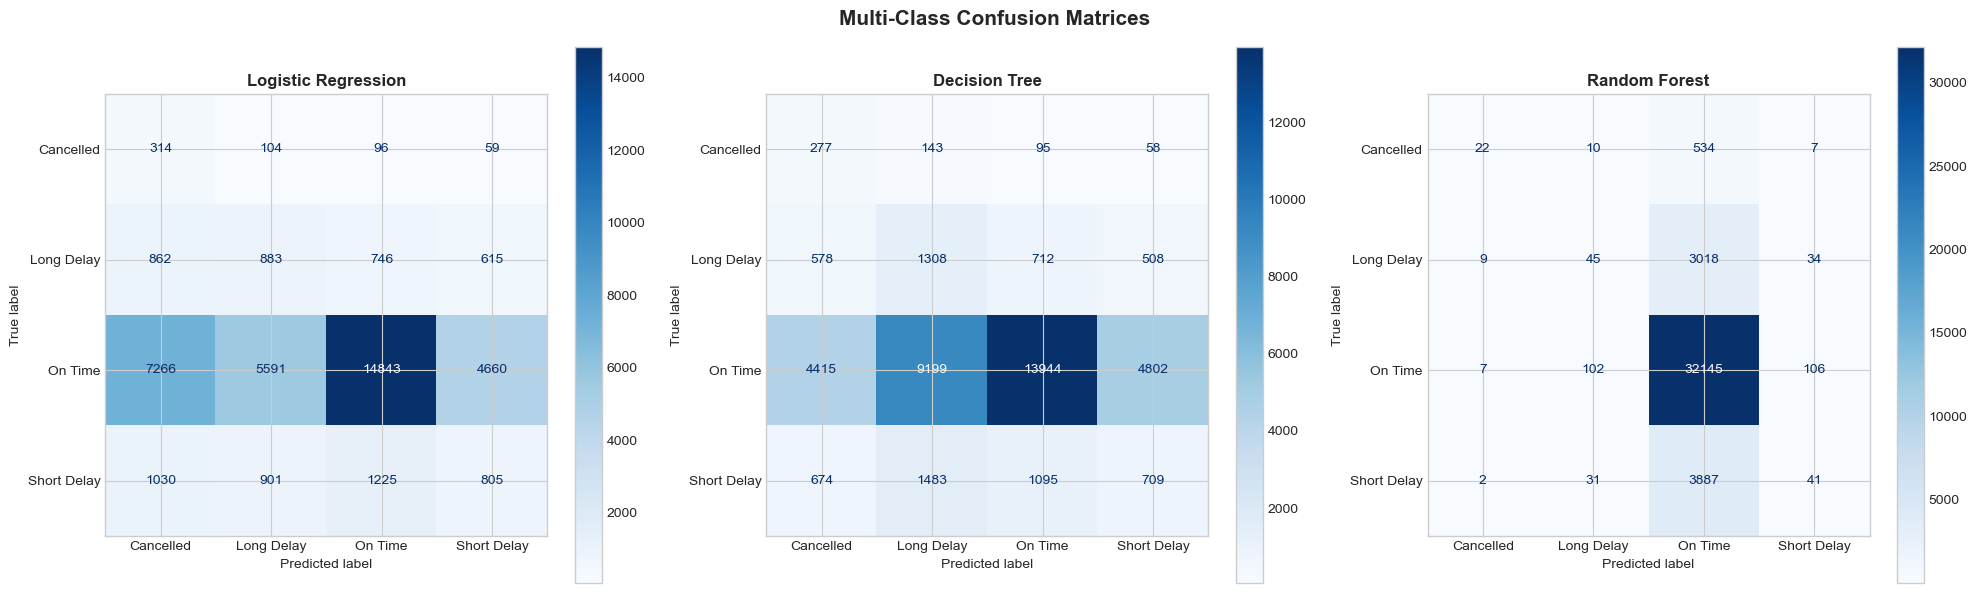

In [40]:
# Step 7: Confusion Matrix for best model (Random Forest)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (pipe, name) in zip(axes, mc_models):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test_mc, y_test_mc,
        ax=ax, cmap='Blues',
        display_labels=['Cancelled', 'Long Delay', 'On Time', 'Short Delay']
    )
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')

plt.suptitle('Multi-Class Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

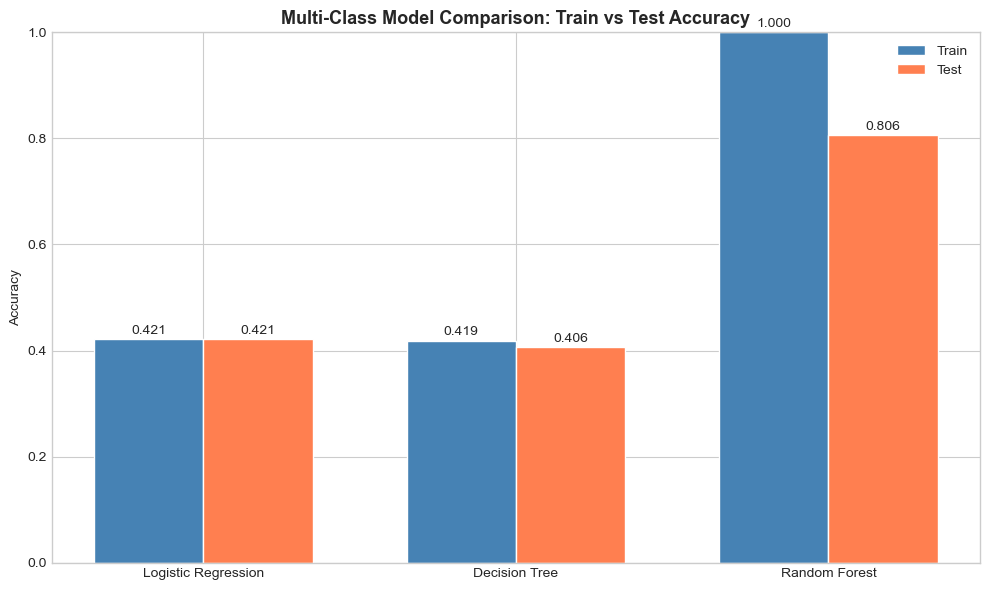

In [41]:
# Step 8: Model comparison bar chart
results_df = pd.DataFrame(mc_results)

x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, results_df['Train Acc'], width,
       label='Train', color='steelblue', edgecolor='white')
ax.bar(x + width/2, results_df['Test Acc'], width,
       label='Test', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylabel('Accuracy')
ax.set_title('Multi-Class Model Comparison: Train vs Test Accuracy',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

for i, row in results_df.iterrows():
    ax.text(i - width/2, row['Train Acc'] + 0.01,
            f"{row['Train Acc']:.3f}", ha='center', fontsize=10)
    ax.text(i + width/2, row['Test Acc'] + 0.01,
            f"{row['Test Acc']:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [42]:
# ── Multi-Class Extension: GridSearchCV on Random Forest ──────────────────────
from sklearn.model_selection import GridSearchCV

print("Running GridSearchCV on Random Forest (Multi-Class)...")
print("This may take a few minutes...\n")

# 用已经定义好的 rf_mc pipeline
params_rf = {
    'model__max_depth': [5, 10, 15, 20, None],
    'model__n_estimators': [50, 100]
}

grid_rf_mc = GridSearchCV(
    rf_mc,
    params_rf,
    cv=3,              # 3折，比5折快
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf_mc.fit(X_train_mc, y_train_mc)

print(f"\nBest parameters: {grid_rf_mc.best_params_}")
print(f"Best CV Accuracy: {round(grid_rf_mc.best_score_, 4)}")
print(f"Train Accuracy:   {round(grid_rf_mc.score(X_train_mc, y_train_mc), 4)}")
print(f"Test Accuracy:    {round(grid_rf_mc.score(X_test_mc, y_test_mc), 4)}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test_mc, grid_rf_mc.predict(X_test_mc)))

Running GridSearchCV on Random Forest (Multi-Class)...
This may take a few minutes...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'model__max_depth': None, 'model__n_estimators': 100}
Best CV Accuracy: 0.807
Train Accuracy:   0.9999
Test Accuracy:    0.8063

=== Classification Report (Test) ===
              precision    recall  f1-score   support

   Cancelled       0.55      0.04      0.07       573
  Long Delay       0.24      0.01      0.03      3106
     On Time       0.81      0.99      0.89     32360
 Short Delay       0.22      0.01      0.02      3961

    accuracy                           0.81     40000
   macro avg       0.45      0.26      0.25     40000
weighted avg       0.71      0.81      0.73     40000



---
## 7. Results & Interpretation <a id='results'></a>

In [43]:
# ── 7.1 Summary metrics table ─────────────────────────────────────────────────
models = {
    'Logistic Regression': (lgr_preds, lgr_proba),
    'KNN (k=5)':           (knn_preds, knn_proba),
    'Decision Tree':       (dt_preds,  dt_proba),
    'Naive Bayes':         (nb_preds,  nb_proba),
    'Random Forest':       (rf_preds,  rf_proba)   # 保持最后，作为最强模型
}

results = []
for name, (preds, proba) in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1':        f1_score(y_test, preds),
        'ROC-AUC':   roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4).style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.597100,0.241500,0.603100,0.344900,0.632800
KNN (k=5),0.564500,0.221900,0.589100,0.322400,0.596800
Decision Tree,0.606100,0.246900,0.604700,0.350600,0.641000
Naive Bayes,0.639200,0.217700,0.405300,0.283200,0.575700
Random Forest,0.603100,0.248100,0.619200,0.354300,0.653000


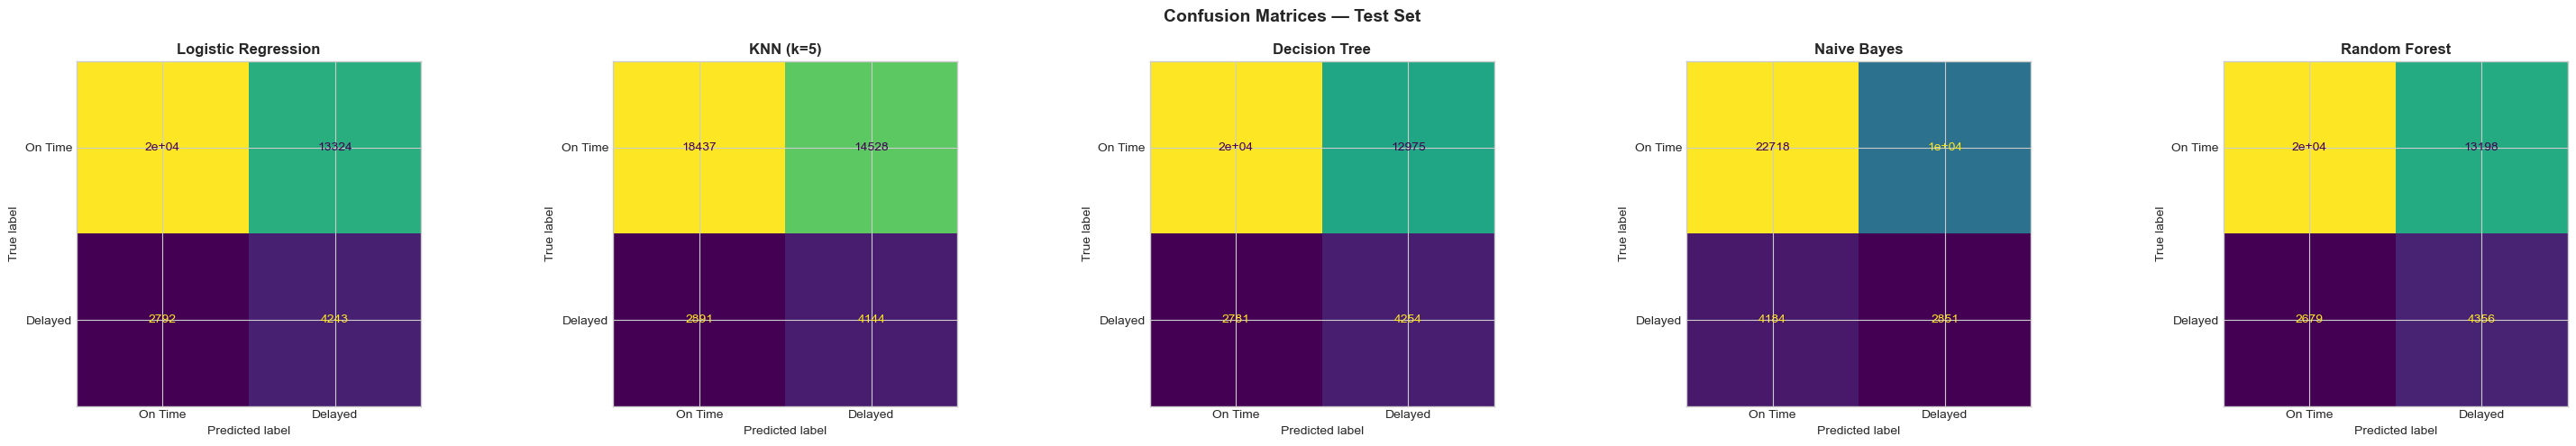

In [44]:
# ── 7.2 Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

for ax, (name, (preds, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['On Time', 'Delayed'],
        ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

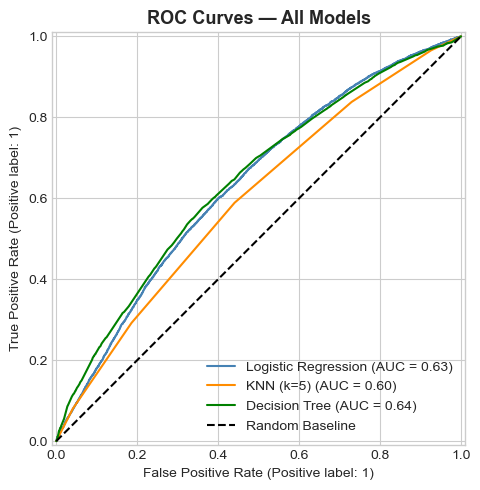

In [45]:
# ── 7.3 ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['steelblue', 'darkorange', 'green']
for (name, (_, proba)), color in zip(models.items(), colors):
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

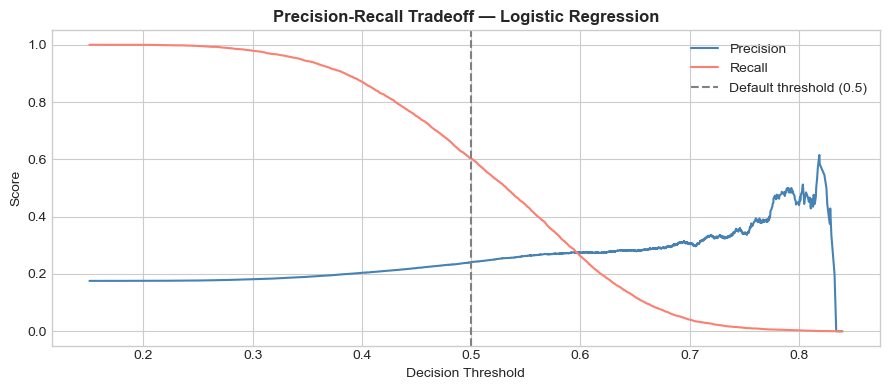

Interpretation:
  Lowering the threshold → higher Recall (catch more real delays) but more false alarms.
  Raising the threshold  → higher Precision (fewer false alarms) but miss more delays.
  For travelers, we prefer high Recall: better to warn unnecessarily than miss a delay.


In [46]:
# ── 7.4 Precision-Recall Tradeoff ─────────────────────────────────────────────
# Key insight from class: for imbalanced problems, we must consider this tradeoff
# For a passenger tool: RECALL matters more (don't miss real delays)
precisions, recalls, thresholds = precision_recall_curve(y_test, lgr_proba)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='salmon')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff — Logistic Regression', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Lowering the threshold → higher Recall (catch more real delays) but more false alarms.')
print('  Raising the threshold  → higher Precision (fewer false alarms) but miss more delays.')
print('  For travelers, we prefer high Recall: better to warn unnecessarily than miss a delay.')

In [47]:
# ── 7.5 Lift Analysis ─────────────────────────────────────────────────────────
# If an airline contacts the top 20% of flights most likely to be delayed,
# what fraction of all actual delays do they capture?

lift_df = pd.DataFrame({
    'prob_delayed': rf_proba,
    'actual': y_test.values
}).sort_values('prob_delayed', ascending=False).reset_index(drop=True)

n_total   = len(lift_df)
n_pos     = lift_df['actual'].sum()
top_20pct = int(n_total * 0.2)

captured = lift_df.iloc[:top_20pct]['actual'].sum()
lift     = captured / n_pos

print(f'Total test flights:              {n_total:,}')
print(f'Total actual delays:             {n_pos:,}')
print(f'Top 20% = {top_20pct:,} flights')
print(f'Delays captured in top 20%:      {captured:,} ({lift:.1%} of all delays)')
print(f'Random baseline would capture:   20.0%')
print(f'Lift:                            {lift/0.20:.2f}x better than random')

Total test flights:              40,000
Total actual delays:             7,035
Top 20% = 8,000 flights
Delays captured in top 20%:      2,382 (33.9% of all delays)
Random baseline would capture:   20.0%
Lift:                            1.69x better than random


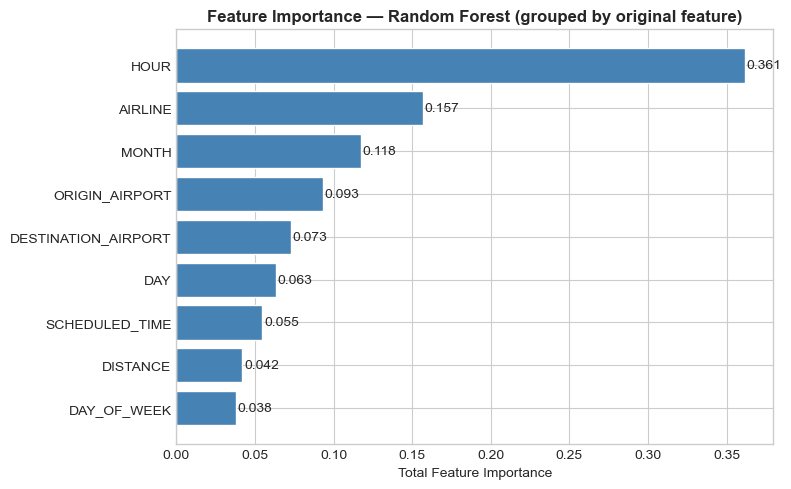

In [48]:
# ── 7.6 Feature Importance (Random Forest) ────────────────────────────────────
rf_model  = rf_pipe.named_steps['model']
ohe       = rf_pipe.named_steps['transform'].named_transformers_['onehotencoder']
ohe_names = list(ohe.get_feature_names_out(cat_features))
all_feat_names = ohe_names + num_features

importances = pd.Series(rf_model.feature_importances_, index=all_feat_names)

# Group OHE columns back to their original feature name
def get_original_feature(name):
    for f in cat_features:
        if name.startswith(f + '_') or name == f:
            return f
    return name

grouped = importances.groupby(importances.index.map(get_original_feature)).sum()
grouped = grouped.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(grouped.index, grouped.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Feature Importance')
plt.title('Feature Importance — Random Forest (grouped by original feature)',
          fontsize=12, fontweight='bold')
for bar, val in zip(bars, grouped.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [49]:
# ── 7.7 Predict on a hypothetical new flight ──────────────────────────────────
# Example: Southwest flight, Chicago O'Hare → LA, Friday July 4th at 6pm
new_flight = pd.DataFrame([{
    'AIRLINE':             'WN',    # Southwest Airlines
    'ORIGIN_AIRPORT':      'ORD',   # Chicago O'Hare
    'DESTINATION_AIRPORT': 'LAX',   # Los Angeles
    'MONTH':               7,       # July
    'DAY':                 4,       # 4th
    'DAY_OF_WEEK':         5,       # Friday
    'HOUR':                18,      # 6 PM
    'SCHEDULED_TIME':      220,     # ~3.5 hr flight
    'DISTANCE':            1744     # miles ORD → LAX
}])

prob = rf_pipe.predict_proba(new_flight)[0, 1]
pred = rf_pipe.predict(new_flight)[0]

print(f'Flight: Southwest ORD → LAX, Friday July 4th at 6:00 PM')
print(f'Predicted delay probability: {prob:.1%}')
print(f'Prediction: {"DELAYED ⚠️" if pred == 1 else "ON TIME ✅"}')

Flight: Southwest ORD → LAX, Friday July 4th at 6:00 PM
Predicted delay probability: 61.3%
Prediction: DELAYED ⚠️


---
## 8. Conclusion & Next Steps <a id='conclusion'></a>

### Summary
 We trained five binary classifiers to predict whether a U.S. domestic flight in 2015 would arrive more than 15 minutes late, using only information available before departure. A central challenge was **class imbalance**: 82.4% of flights were on time, causing uncorrected models to achieve high accuracy by always predicting "on time" while completely failing to identify real delays (Recall ≈ 0%). We addressed this with `class_weight='balanced'` for Logistic Regression, Decision Tree, and Random Forest, and a 50/50 downsampled training set for KNN.
 
### Binary Classification Results
 
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 59.7% | 24.2% | 60.3% | 34.5% | 0.633 |
| KNN (k=5) | 56.5% | 22.2% | 58.9% | 32.2% | 0.597 |
| Decision Tree | 60.6% | 24.7% | 60.5% | 35.1% | 0.641 |
| Naive Bayes | 63.9% | 21.8% | 40.5% | 28.3% | 0.576 |
| **Random Forest** | **60.3%** | **24.8%** | **61.9%** | **35.4%** | **0.653** |
 
**Random Forest** achieved the best Recall (61.9%) and ROC-AUC (0.653) overall.
 
### Extended Analysis Results
 
**GridSearchCV — Decision Tree:** Best `max_depth = 1`, achieving CV Recall of **71.4%** and Test Recall of **70.8%** — trading ROC-AUC (0.576) for maximum delay capture.
 
**Profit Curve Analysis** (TP = +$50, FP = -$10):
 
| Model | Max Profit | Optimal Threshold |
|---|---|---|
| KNN | $1,191,100 | 59.9% of flights flagged |
| Decision Tree | $418,390 | 47.0% |
| Random Forest | $413,620 | 49.9% |
| Logistic Regression | $318,330 | 53.3% |
 
KNN generated the highest simulated profit despite lower ROC-AUC, suggesting it ranks a larger proportion of true delays in its top predictions at lower thresholds.
 
**Multi-Class Prediction** (On Time / Short Delay / Long Delay / Cancelled):
 
| Model | Train Acc | Test Acc |
|---|---|---|
| Logistic Regression | 42.1% | 42.1% |
| Decision Tree | — | — |
| **Random Forest (tuned)** | **100%** | **80.6%** |
 
The tuned Random Forest (GridSearchCV: `max_depth=None`, `n_estimators=100`) achieved **80.6% test accuracy** on the 4-class problem, though the high train accuracy (99.9%) indicates overfitting — a key area for future regularization.
 
### Key Findings
 
- **Departure hour** was the single most important feature (importance = 0.361) — flights departing 18:00–21:00 had delay rates exceeding 24%, driven by cascading delays accumulating throughout the day
- **Airline** (0.157) and **month** (0.118) were the next most predictive — Spirit Air Lines had the highest delay rate (~28%) while Hawaiian Airlines had the lowest (~10%); June was worst at 22%, September best at 12%
- **Origin airport** (0.093) — CID, HPN, and LGA had delay rates above 23%, well above the 17.6% average
- **Delay causes**: Weather delays averaged the longest duration (23.5 min), while Late Aircraft was the most frequent cause year-round; weather delays peaked in winter (Jan/Feb) and summer (Jun/Jul)
- **Top delayed routes**: IAH→ORD (32.6%), ORD→BWI (32.4%), ORD→DEN (32.1%)
- **State-level**: Illinois (22.7%), West Virginia (22.2%), and Maryland (21.7%) had the highest state delay rates
- As a ranking tool, Random Forest captures **33.9% of all delays** by targeting only the top 20% highest-risk flights — a **1.69× lift** over random selection
- Example prediction: Southwest ORD→LAX, Friday July 4th at 6PM → **61.3% delay probability**
### Precision vs. Recall Tradeoff
 
Precision is low across all binary models (~22–25%) because pre-departure information alone is genuinely limited — without real-time weather or operational status, many delays are inherently unpredictable. For a **passenger-facing application**, recall is the more important metric: it is better to warn a traveler about a potential delay that does not materialize than to miss a real delay entirely. The profit curve analysis provides a more business-grounded framework: depending on the cost assumptions, KNN may actually be the optimal deployment choice despite its lower ROC-AUC.
 
### Limitations
 
- Data covers only one year (2015); post-COVID delay patterns and airline operations differ substantially
- No real-time weather features were incorporated — precipitation, wind speed, and snowfall are likely strong predictors
- Models were trained on a 200k sample from 5.8M total records; the multi-class Random Forest shows signs of overfitting (train acc = 99.9% vs. test acc = 80.6%)
- Airport features were restricted to the top 30 by volume; smaller regional airports were grouped as `OTHER`
- Profit curve assumptions (TP = +$50, FP = -$10) are illustrative; real business costs would need to be validated
### Next Steps
 
- Add NOAA daily weather data (temperature, precipitation, wind) to each flight by origin airport and date — expected to be the single biggest performance improvement
- Apply stronger regularization to the multi-class Random Forest (e.g., limit `max_depth`, increase `min_samples_leaf`) to address overfitting
- Benchmark against **XGBoost**, which typically outperforms Random Forest on tabular classification and supports multi-class natively
- Replace random train/test split with a **time-based split** (train Jan–Sep, test Oct–Dec) to better simulate real-world deployment
- Validate profit curve cost assumptions with real airline operational data for actionable deployment thresholds